###### Jason Mrad 202400809 | Jean Abi Khalil 202302369 | Jean Paul Hatem 202400360 | Isabelle Nigolian 202302736

# Medical Cost Insurance Model

### Step-1- Import Libraries

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

import xgboost
import lightgbm

import joblib

### Step-2- Load DataSet

In [2]:
# Load dataset
df = pd.read_csv('../data/medical_insurance.csv')
columns = df.columns
target = 'annual_medical_cost'
RANDOM_STATE = 42

warnings.filterwarnings("ignore", category=FutureWarning)

# Split columns
categorical_cols = [
    'sex', 'region', 'urban_rural', 'marital_status', 
    'education', 'employment_status', 'smoker',
    'alcohol_freq', 'plan_type', 'network_tier'
]
numerical_cols = [col for col in columns if col not in categorical_cols]

# -----------------------------
# Dataset overview
# -----------------------------
print("Dataset preview:")
display(df.head())  

print("\nDataset info:")
df.info()

print("\nMissing values per column:")
print(df.isna().sum())

print("\nNumerical summary:")
display(df[numerical_cols].describe().round(2))

print("\nCategorical summary:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("-"*40)

print("\nShape of dataset:", df.shape)
print("Number of numeric columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Dataset preview:


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,1.0,Married,1.0,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,4.0,Married,0.0,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,2.0,Married,1.0,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,5.0,Married,2.0,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,1.0,Married,2.0,2,...,0,1,0,2,0,1,1,0,1,0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99990 entries, 0 to 99989
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    99990 non-null  int64  
 1   age                          99990 non-null  int64  
 2   sex                          99990 non-null  object 
 3   region                       99990 non-null  object 
 4   urban_rural                  99990 non-null  object 
 5   income                       99990 non-null  float64
 6   education                    99990 non-null  float64
 7   marital_status               99990 non-null  object 
 8   employment_status            99990 non-null  float64
 9   household_size               99990 non-null  int64  
 10  dependents                   99990 non-null  int64  
 11  bmi                          99990 non-null  float64
 12  smoker                       99990 non-null  float64
 13  a

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,99990.00,99990.00,99990.00,99990.00,99990.00,99990.00,99990.00,99990.00,99990.00,99990.00,...,99990.00,99990.00,99990.00,99990.00,99990.00,99990.00,99990.00,99990.00,99990.00,99990.00
mean,49998.98,47.52,49872.92,2.43,0.90,26.99,1.93,0.09,0.37,1.24,...,0.01,0.11,0.13,0.51,0.16,0.51,0.51,0.51,0.37,0.17
std,28868.00,15.99,46801.27,1.08,0.95,4.99,1.74,0.30,1.37,1.21,...,0.12,0.31,0.34,0.75,0.46,0.75,0.75,0.75,0.48,0.38
min,1.00,0.00,1100.00,1.00,0.00,12.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,24998.25,37.00,21100.00,2.00,0.00,23.60,1.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,49998.50,48.00,36200.00,2.00,1.00,27.00,2.00,0.00,0.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,74999.75,58.00,62200.00,3.00,1.00,30.40,3.00,0.00,0.00,2.00,...,0.00,0.00,0.00,1.00,0.00,1.00,1.00,1.00,1.00,0.00
max,100000.00,100.00,1061800.00,9.00,7.00,50.40,25.00,3.00,21.00,11.00,...,1.00,1.00,1.00,7.00,6.00,7.00,7.00,7.00,1.00,1.00



Categorical summary:

Column: sex
sex
Female    49187
Male      48790
Other      2013
Name: count, dtype: int64
----------------------------------------

Column: region
region
South      28026
North      22025
East       19982
West       17878
Central    12079
Name: count, dtype: int64
----------------------------------------

Column: urban_rural
urban_rural
Urban       60013
Suburban    25019
Rural       14958
Name: count, dtype: int64
----------------------------------------

Column: marital_status
marital_status
Married     53246
Single      35713
Divorced     6982
Widowed      4049
Name: count, dtype: int64
----------------------------------------

Column: education
education
0.0    27995
5.0    25109
2.0    24826
3.0    13984
4.0     5119
1.0     2957
Name: count, dtype: int64
----------------------------------------

Column: employment_status
employment_status
0.0    55263
1.0    19863
3.0    12938
2.0    11926
Name: count, dtype: int64
----------------------------------------



### Step-3- Data Analysis

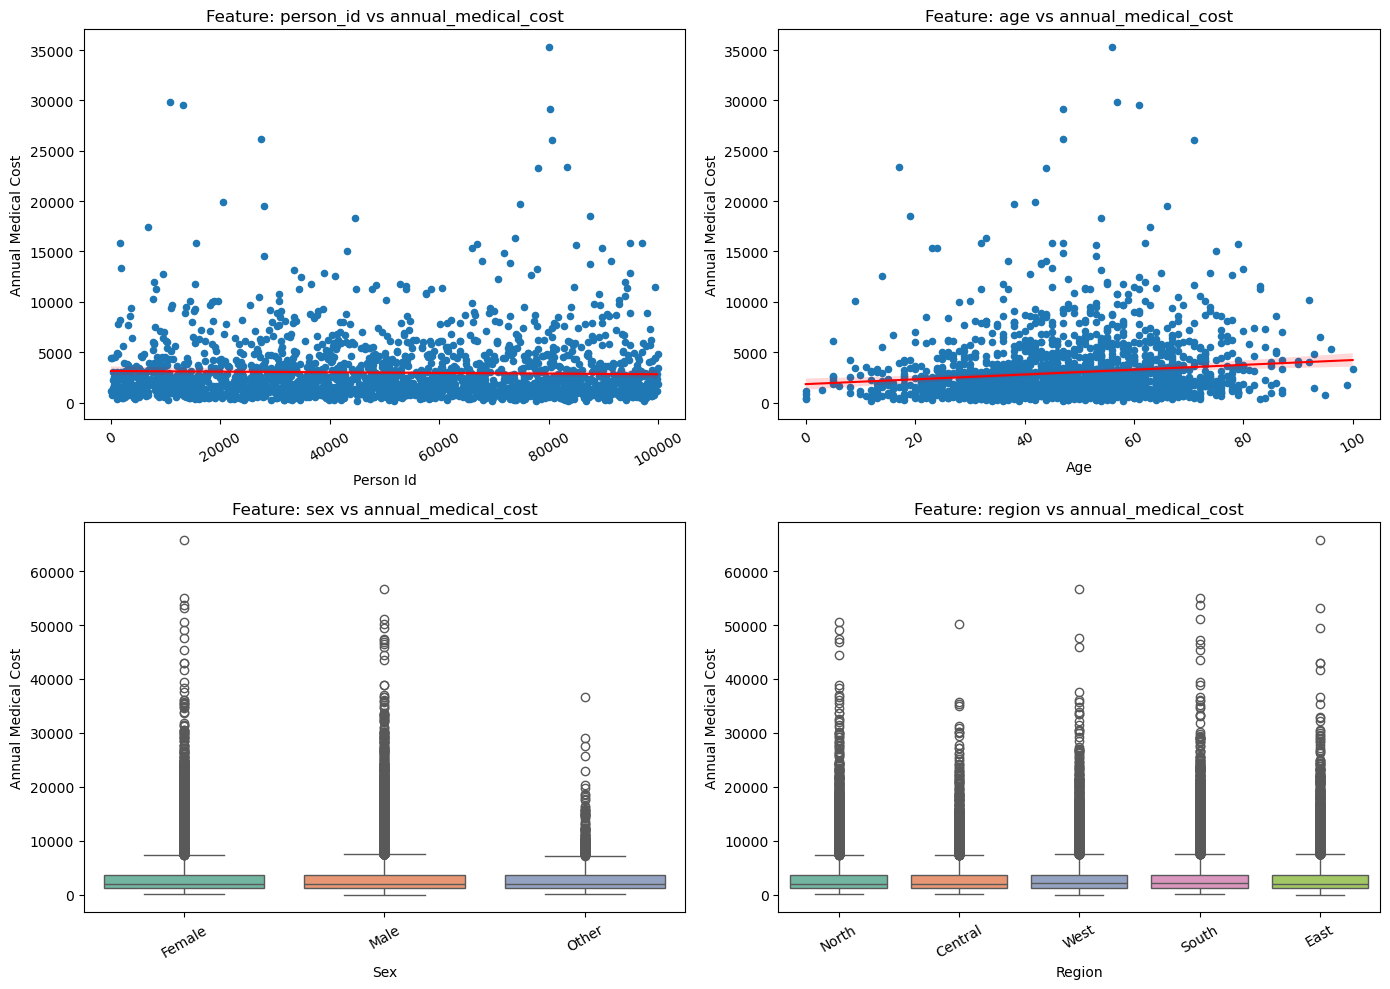

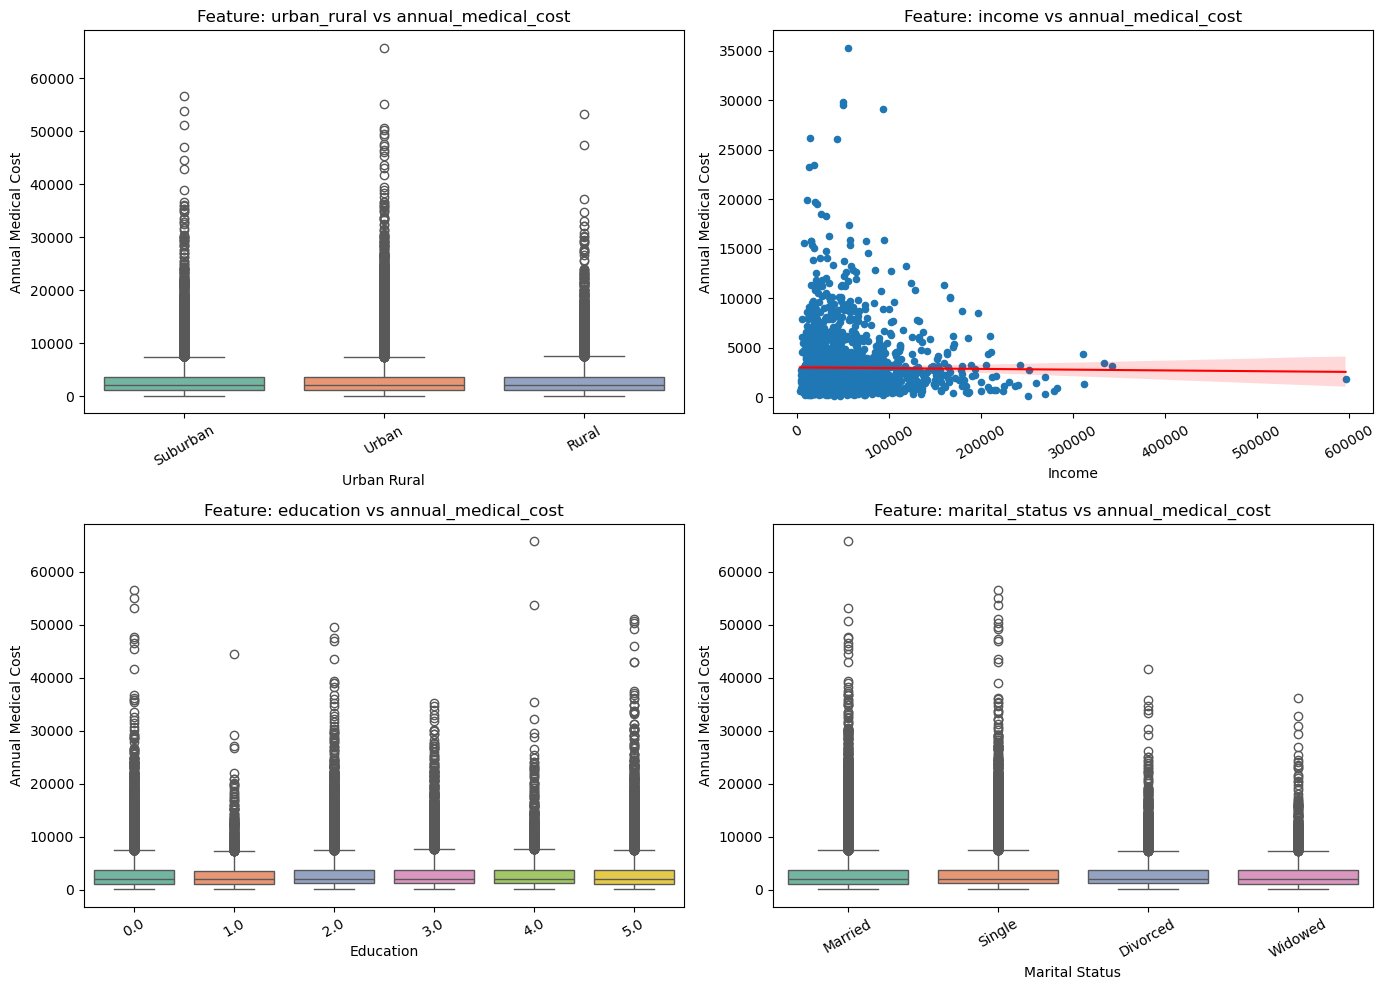

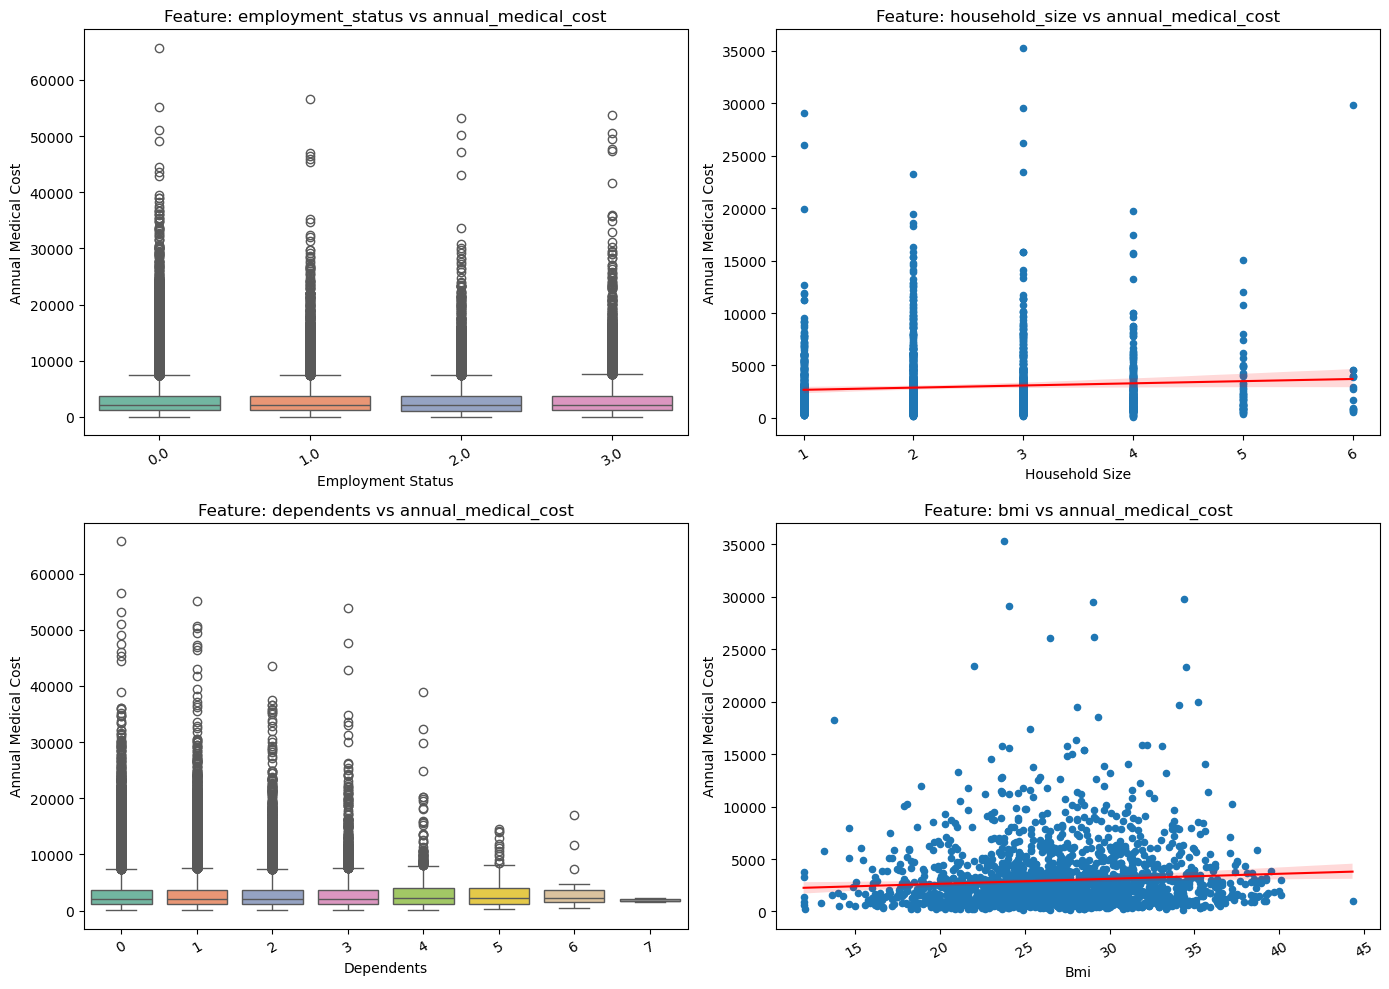

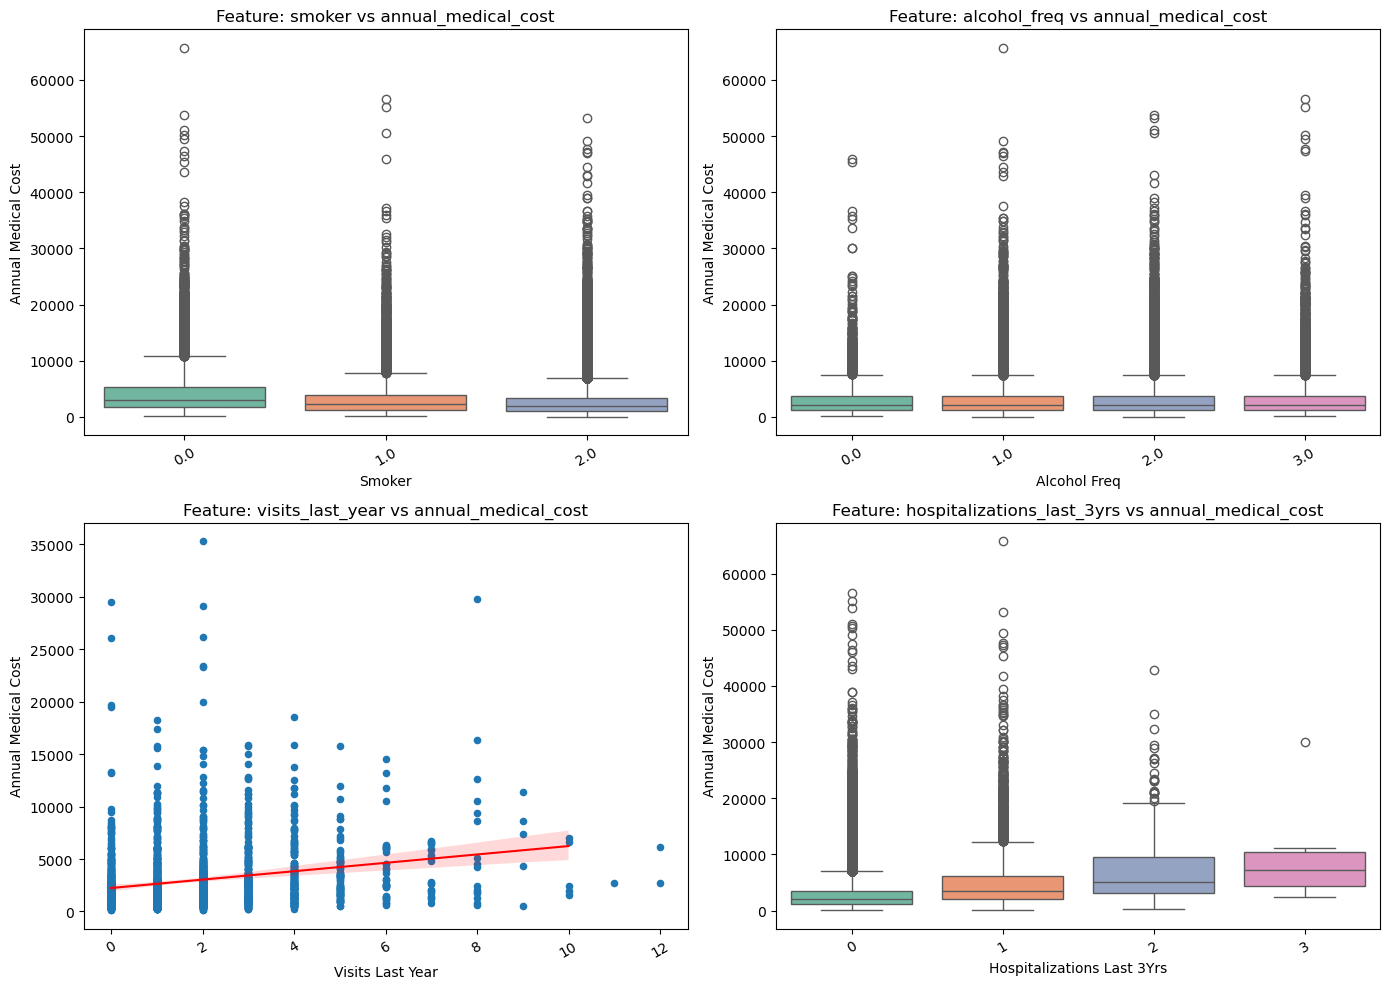

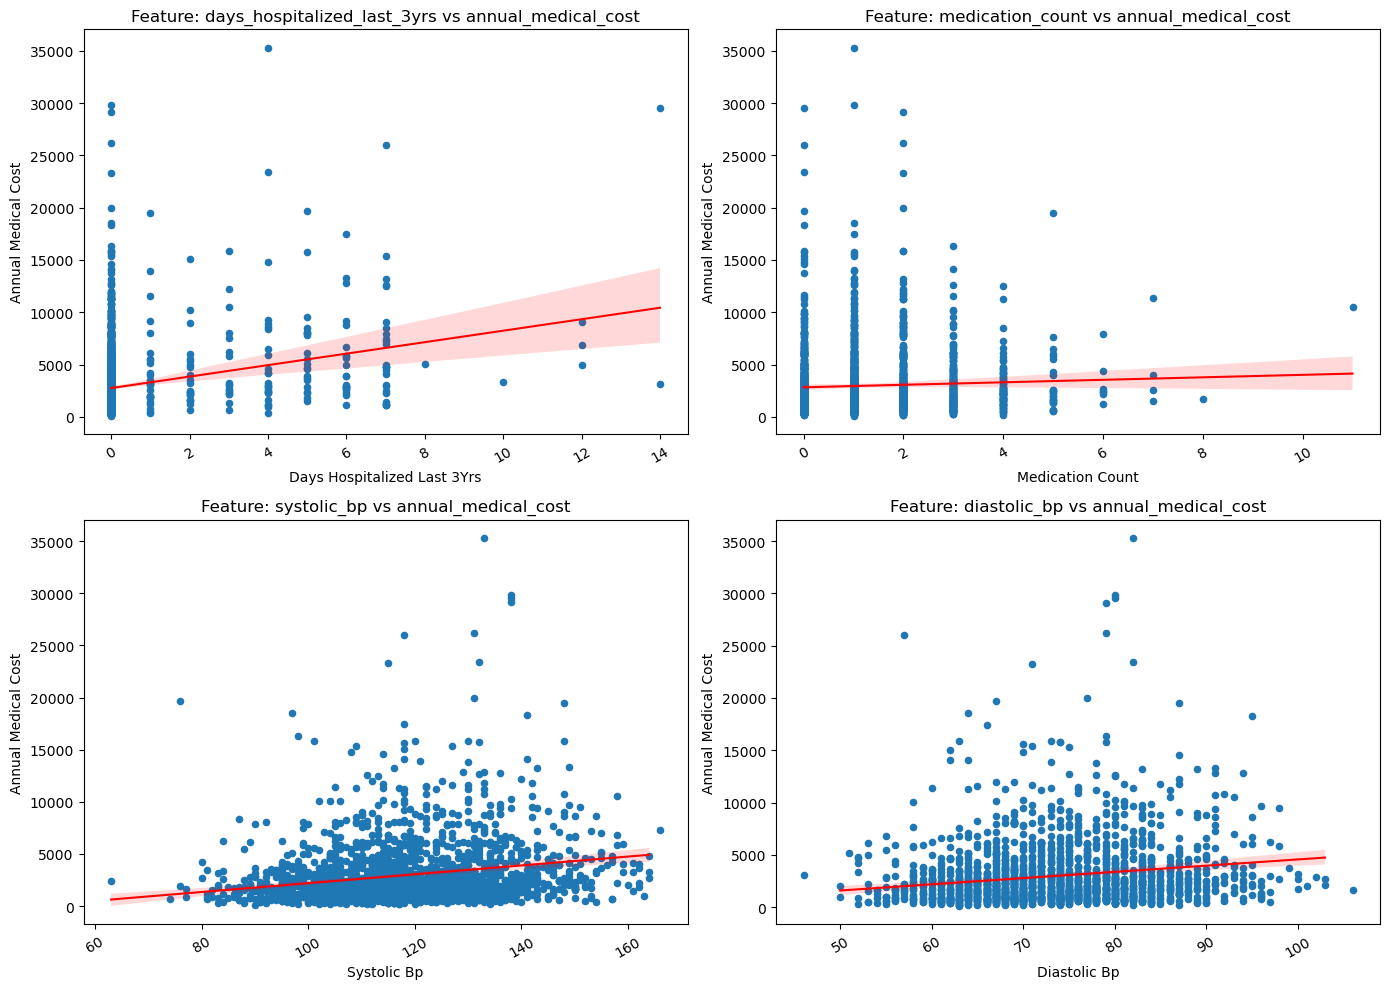

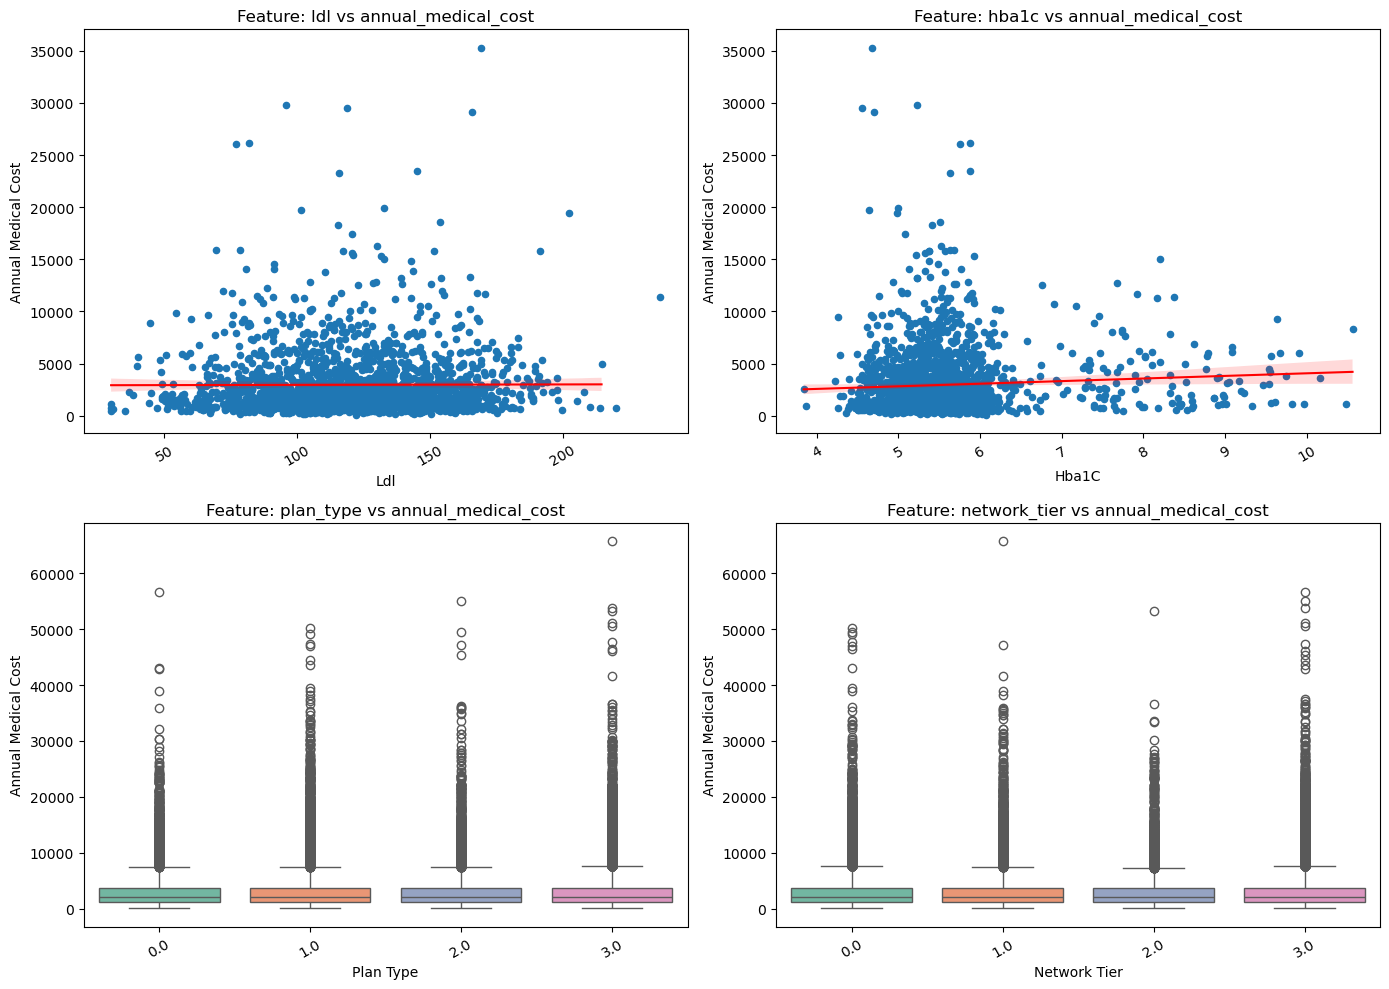

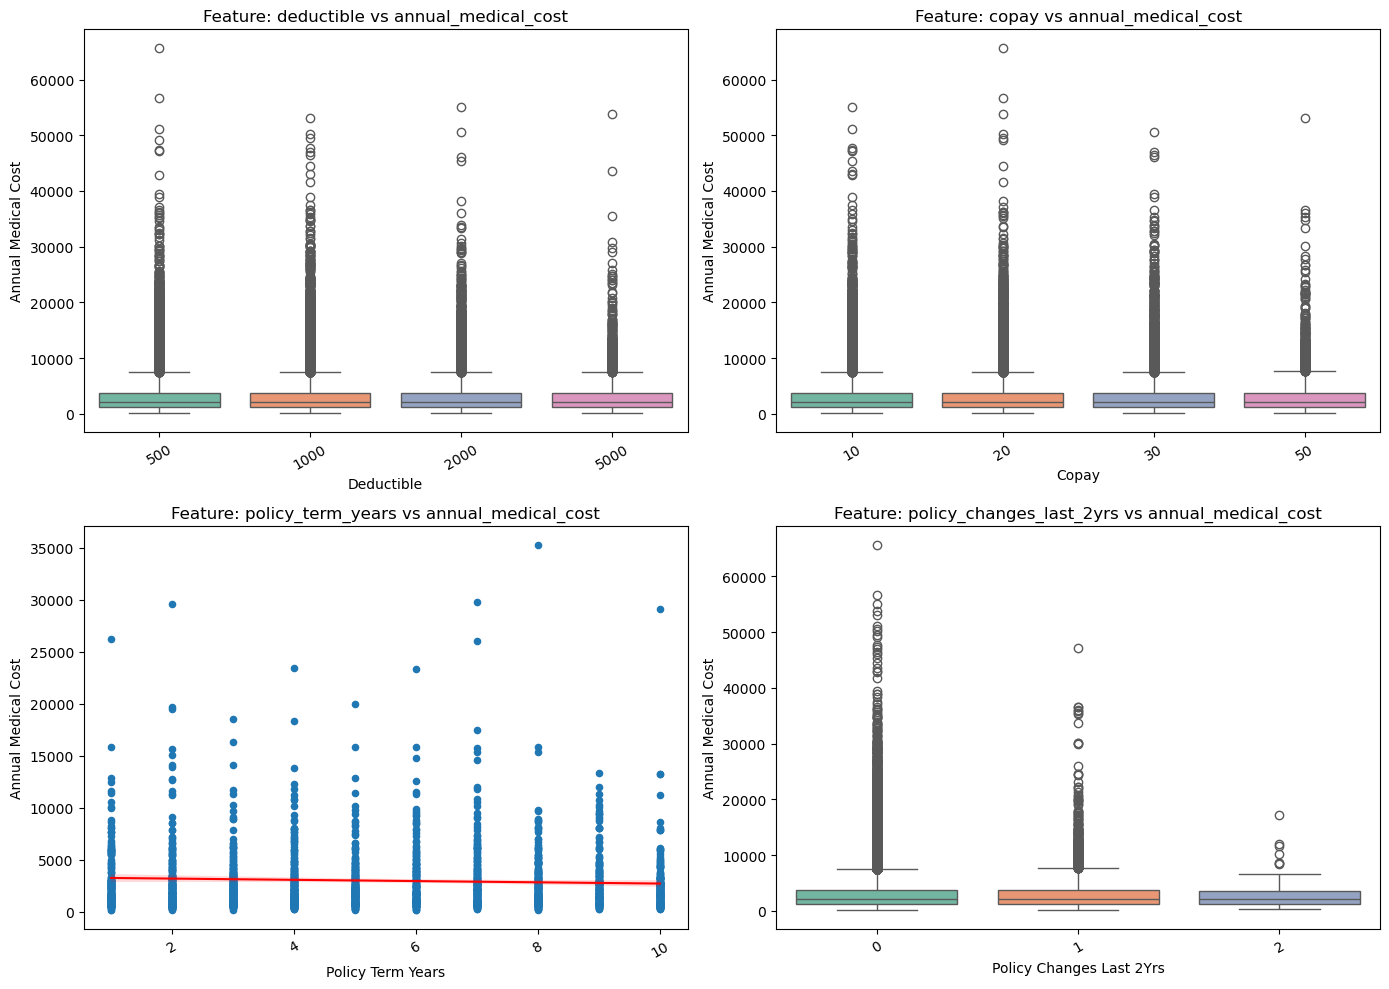

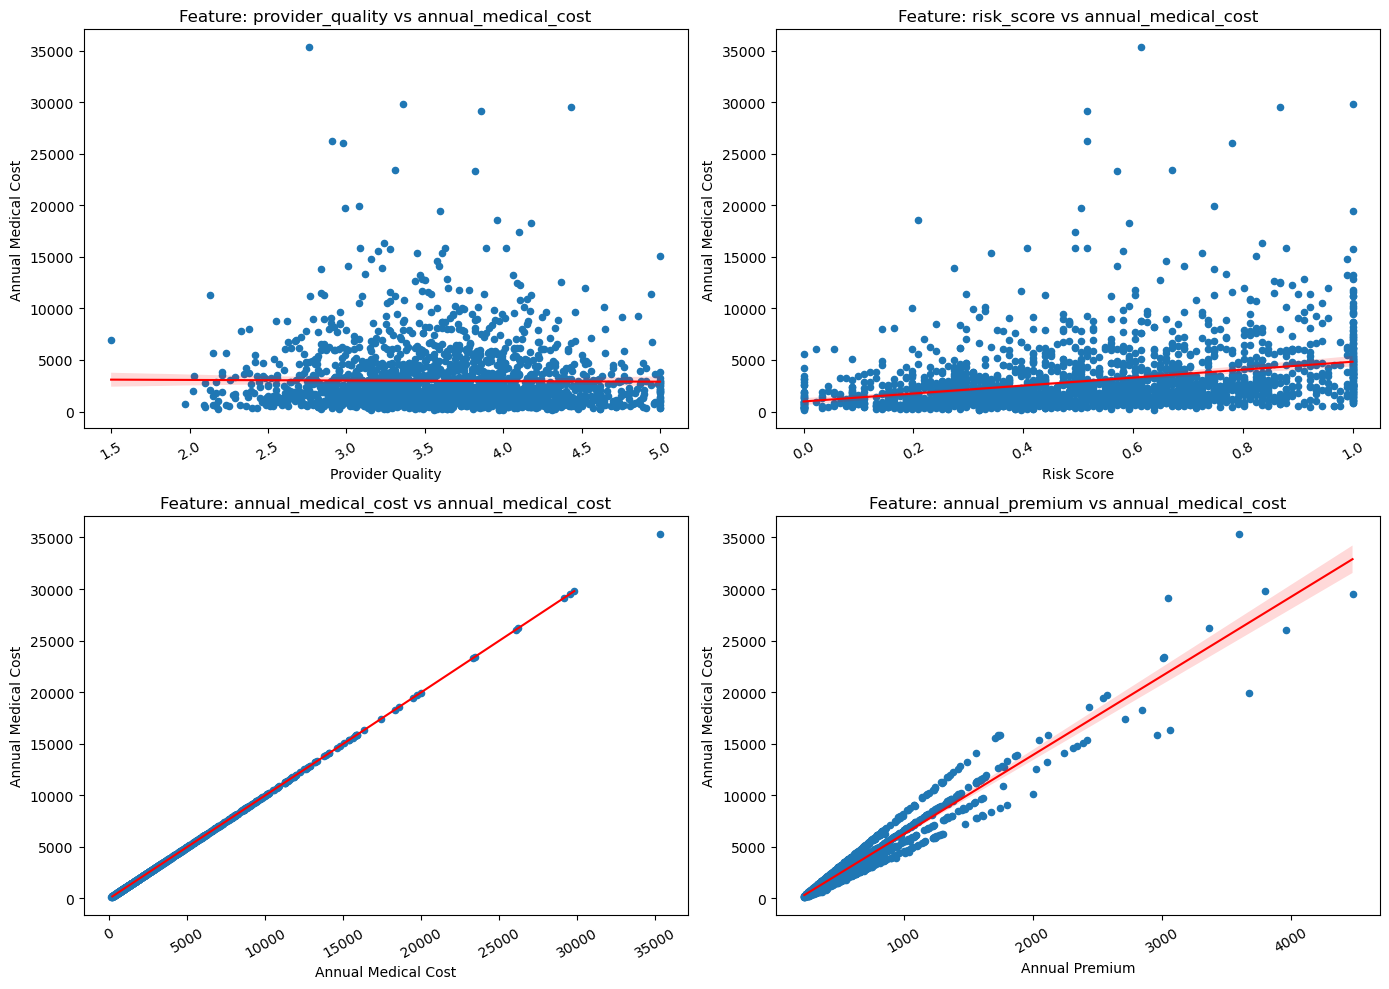

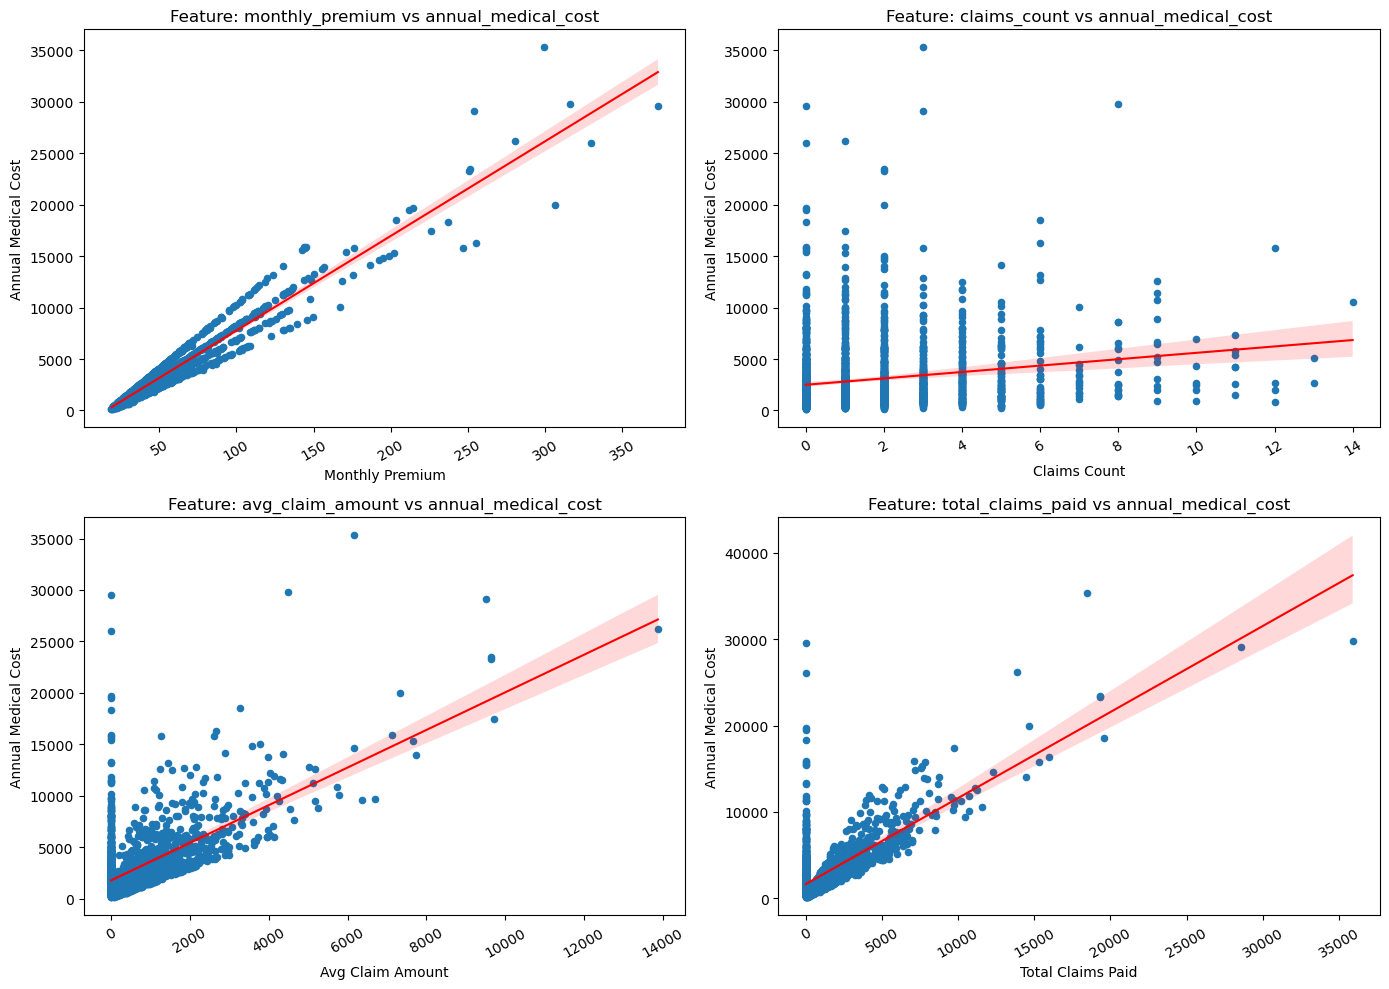

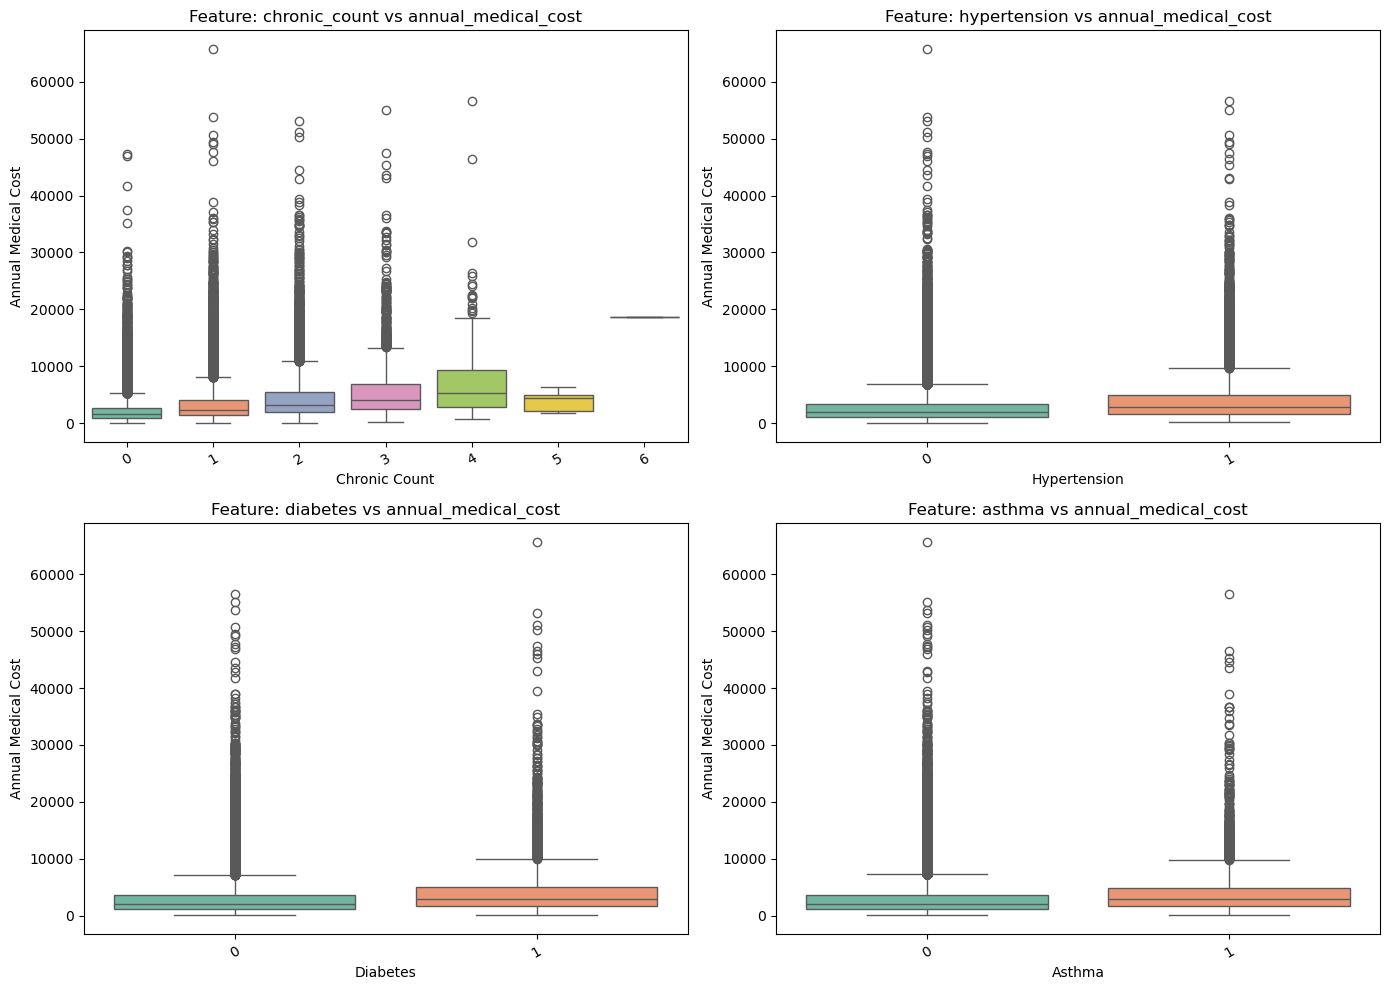

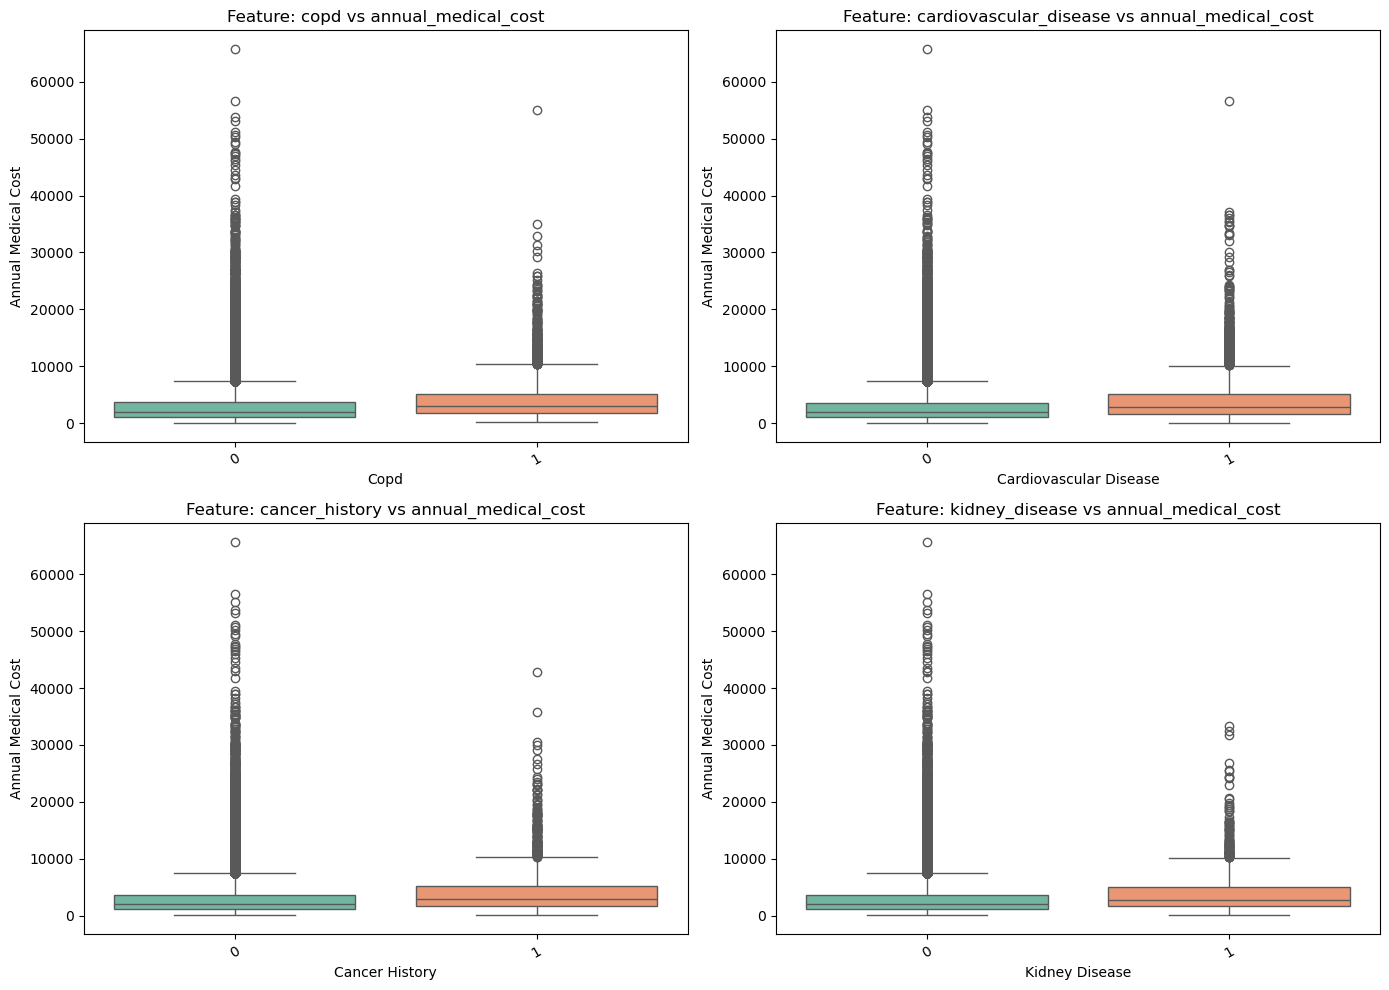

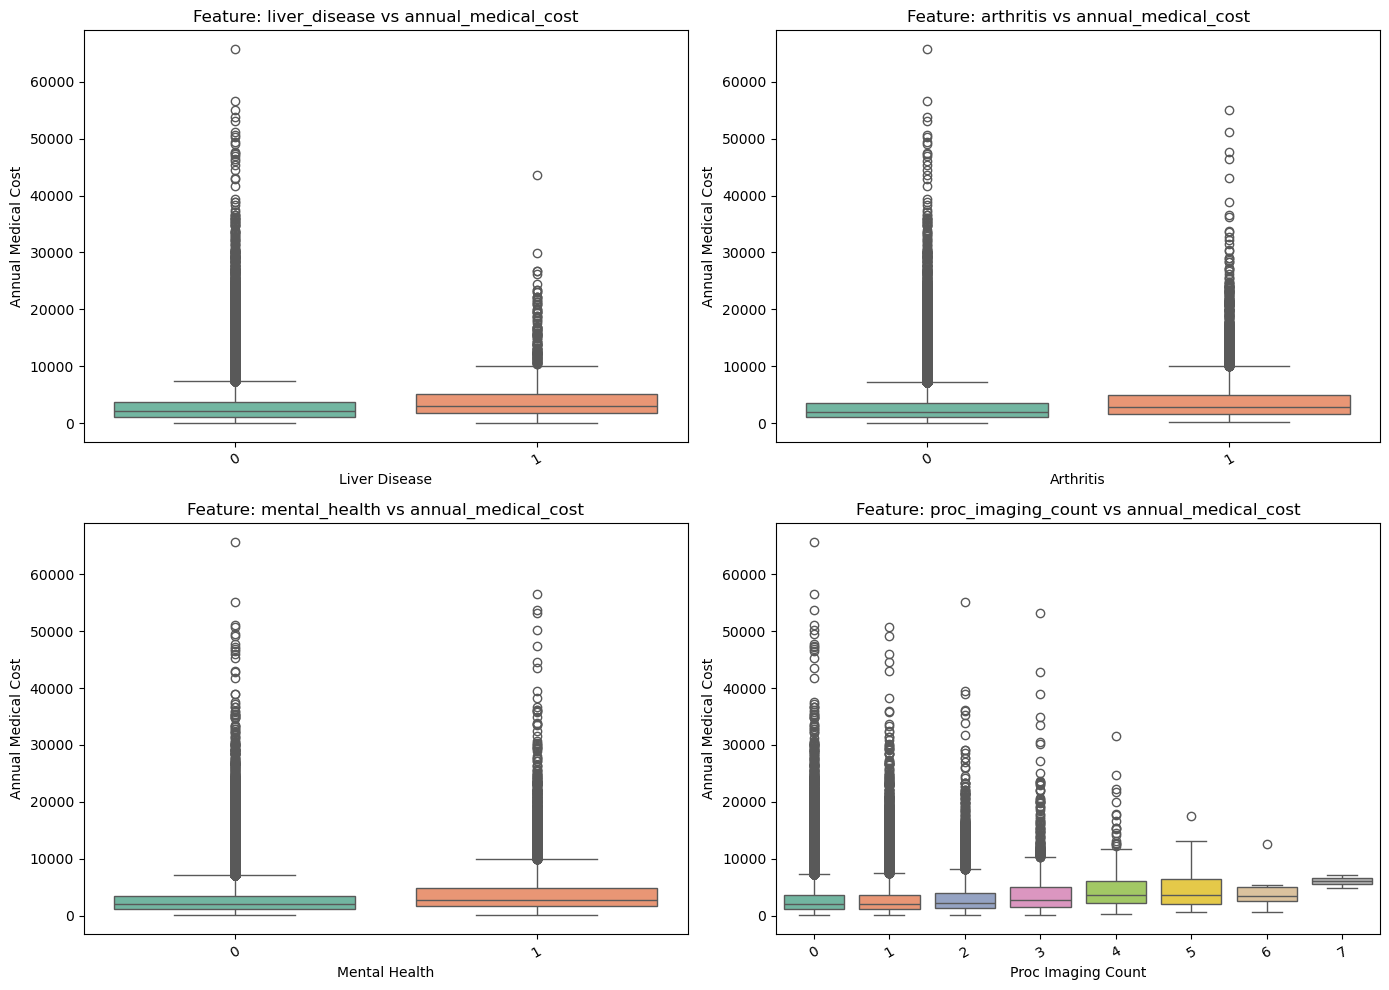

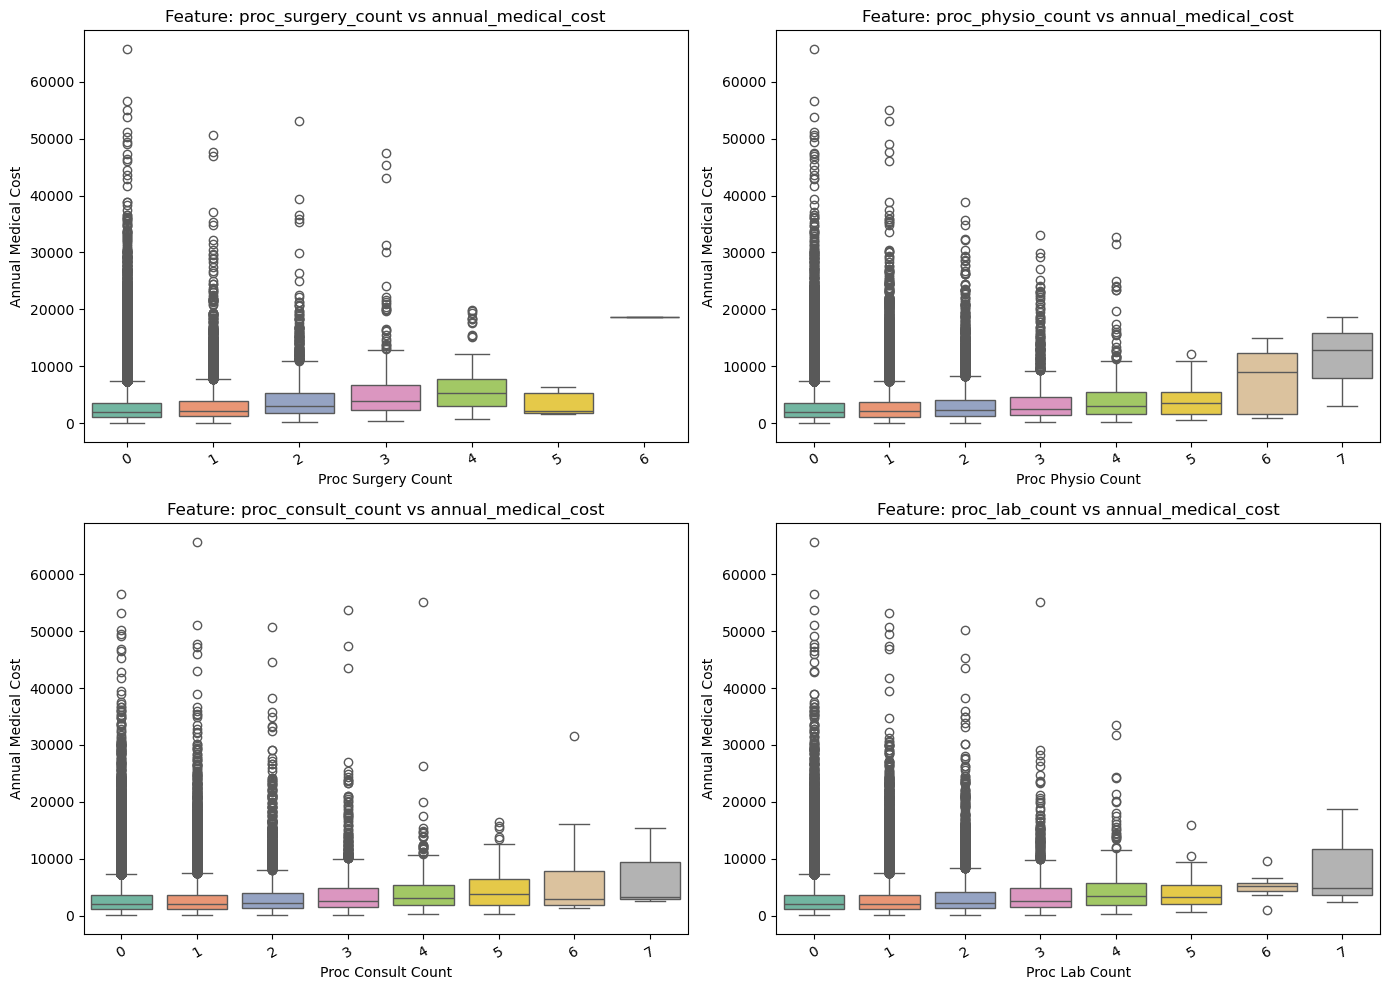

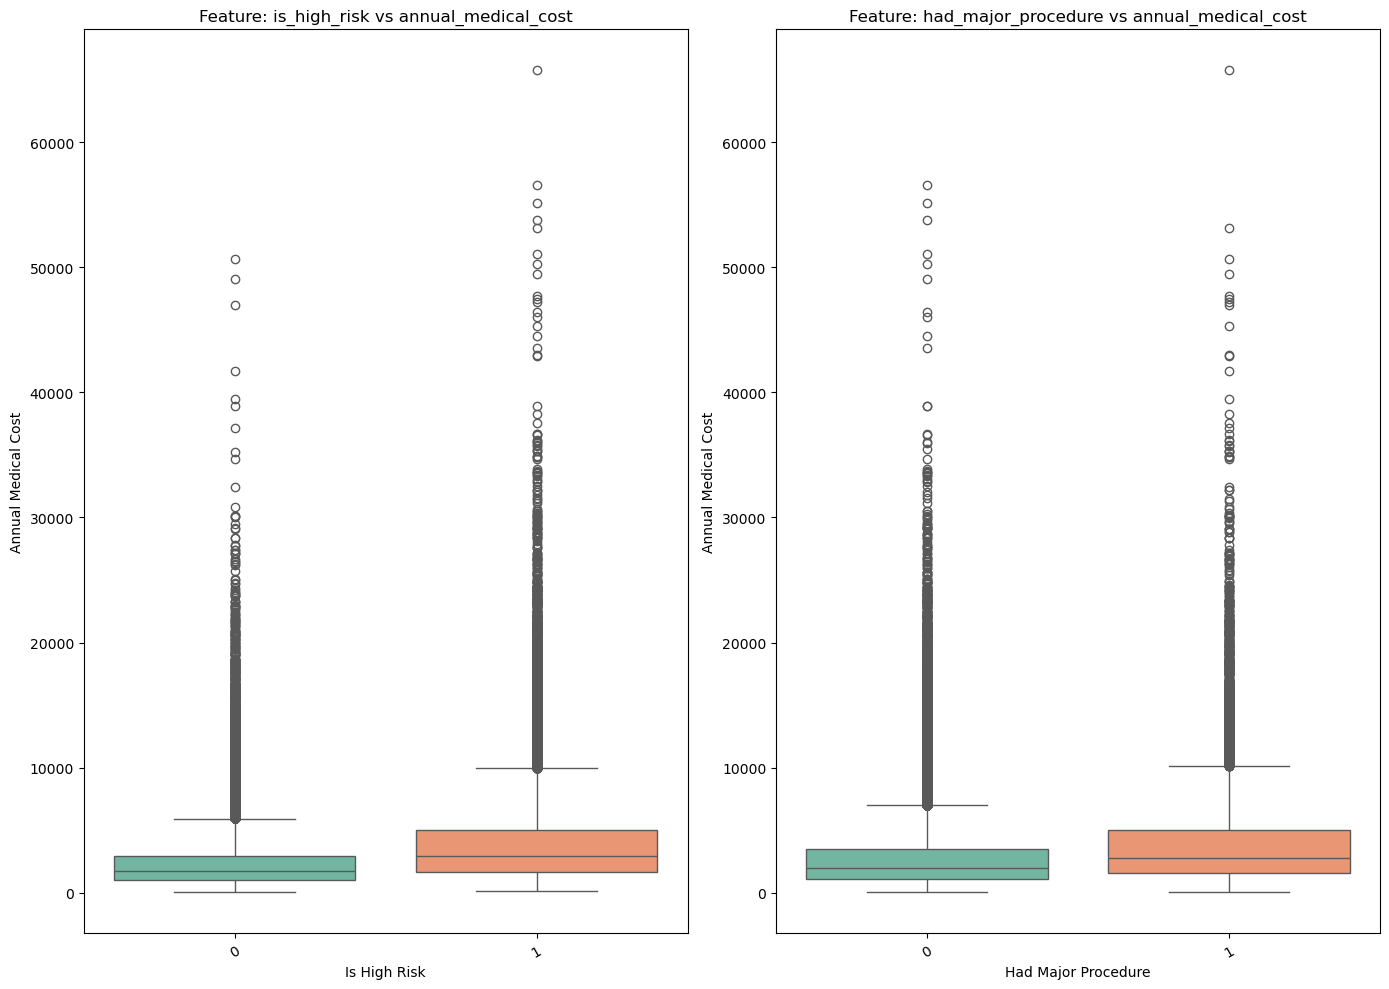

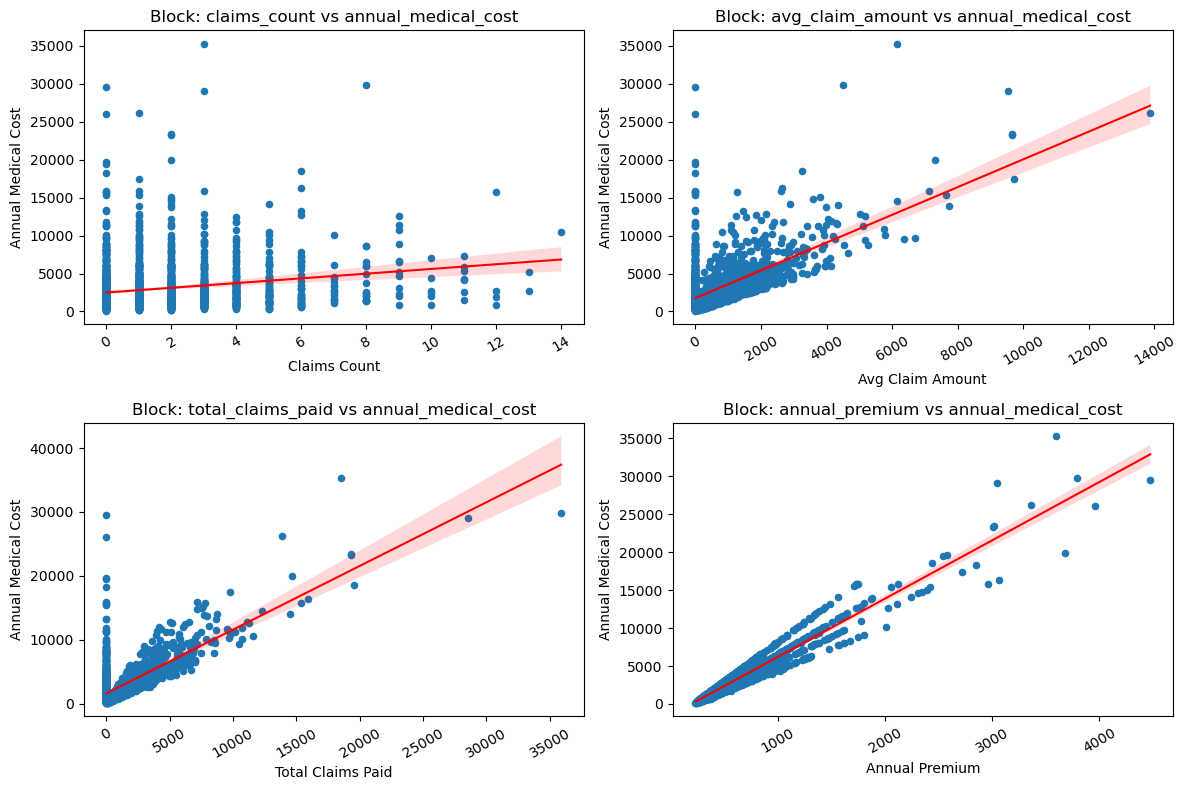

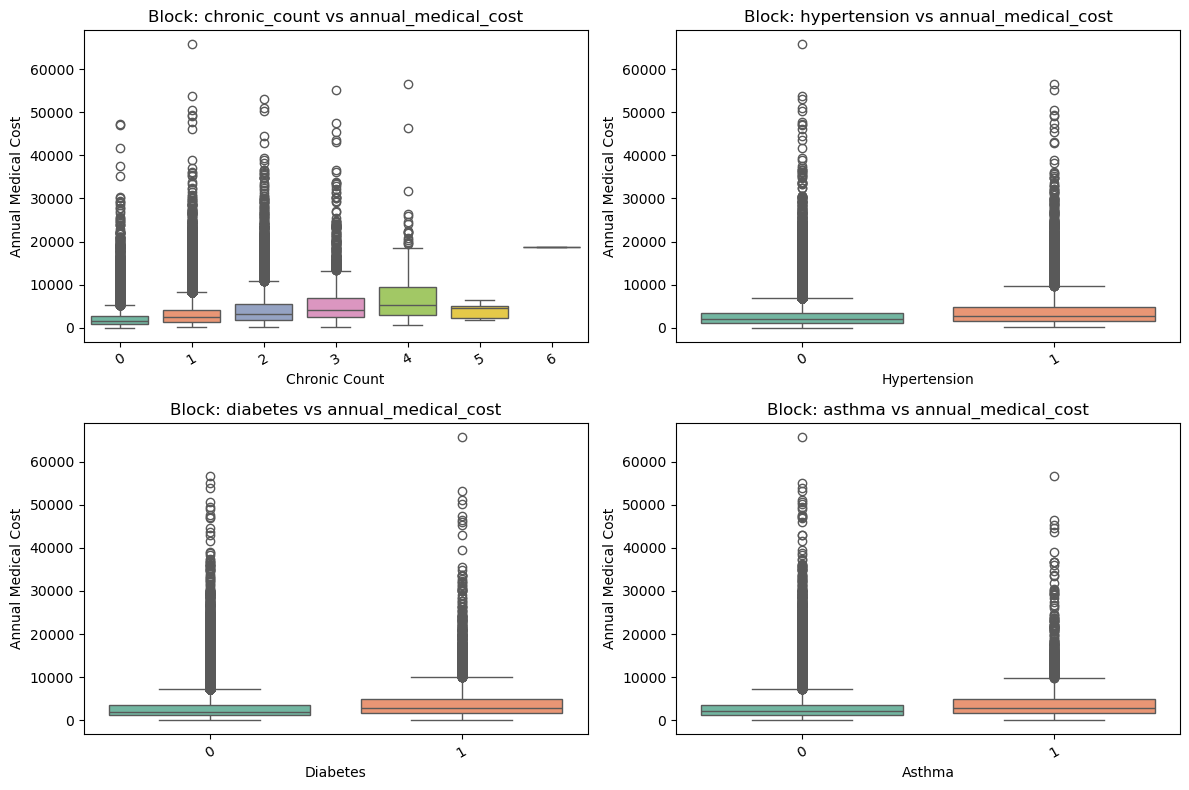

In [3]:
def plot_batch(df_local, cols, title_prefix="", show=True, ncols=2, figsize=(14,10)):
    if not show:
        return

    n = len(cols)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols):
        ax = axes[i]
        try:
            # categorical -> boxplot
            if df_local[col].dtype == 'O' or df_local[col].nunique() <= 8:
                sns.boxplot(
                    x=col, y=target, data=df_local, ax=ax,
                    hue=None, palette="Set2", dodge=False
                )
            else:
                # numeric -> matplotlib scatter (translucent blue) + seaborn regplot for line
                df_sample = df_local.sample(min(len(df_local), 2000), random_state=42)
                ax.scatter(df_sample[col], df_sample[target], s=20)
                # regression line using seaborn (scatter turned off, solid red)
                try:
                   sns.regplot(
                        x=col, y=target,
                        data=df_sample.sample(min(len(df_sample), 1000), random_state=42),
                        scatter=False, ax=ax,
                        line_kws={'linewidth':1.5, 'color':'red'}
                    )
                except Exception:
                    # fallback: simple numpy polyfit
                    clean = df_sample[[col, target]].dropna()
                    if len(clean) > 1:
                        coeffs = np.polyfit(clean[col].astype(float), clean[target].astype(float), 1)
                        xs = np.linspace(clean[col].min(), clean[col].max(), 100)
                        ax.plot(xs, coeffs[0]*xs + coeffs[1], color='red', linewidth=1.5)

            ax.set_xlabel(col.replace('_', ' ').title())
            ax.set_ylabel('Annual Medical Cost')
            ax.set_title(f"{title_prefix}{col} vs {target}")
            ax.tick_params(axis='x', rotation=30)

        except Exception as e:
            ax.text(0.5, 0.5, f"Error plotting {col}\n{e}", ha='center', va='center')
            ax.set_axis_off()

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
    
batch_size = 4
for i in range(0, len(columns), batch_size):
    batch = columns[i:i+batch_size]
    plot_batch(df, batch, title_prefix="Feature: ")

special_blocks = [
    [c for c in ['claims_count', 'avg_claim_amount', 'total_claims_paid', 'annual_premium'] if c in df.columns],
    [c for c in ['chronic_count', 'hypertension', 'diabetes', 'asthma'] if c in df.columns]
]
for blk in special_blocks:
    if blk:
        plot_batch(df, blk, title_prefix="Block: ", figsize=(12,8))

In [4]:
ord_cols = [
    'education', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier'
]
onehot_cols = [
    'sex', 'region', 'urban_rural', 'marital_status'
]
# Alcohol freq imputation
df['alcohol_freq'] = df['alcohol_freq'].fillna('Never')

# For one-hot encoding
Hotencoder = OneHotEncoder(sparse_output=False)
encoded_features = Hotencoder.fit_transform(df[onehot_cols])


# For ordinal encoding
Ordencoder = OrdinalEncoder()
df[ord_cols] = Ordencoder.fit_transform(df[ord_cols])

# Get the feature names from the encoder
feature_names = Hotencoder.get_feature_names_out(onehot_cols)

# Create a DataFrame with the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=df.index)

# Drop the original categorical columns and join the encoded ones
df = df.drop(onehot_cols, axis=1).join(encoded_df)

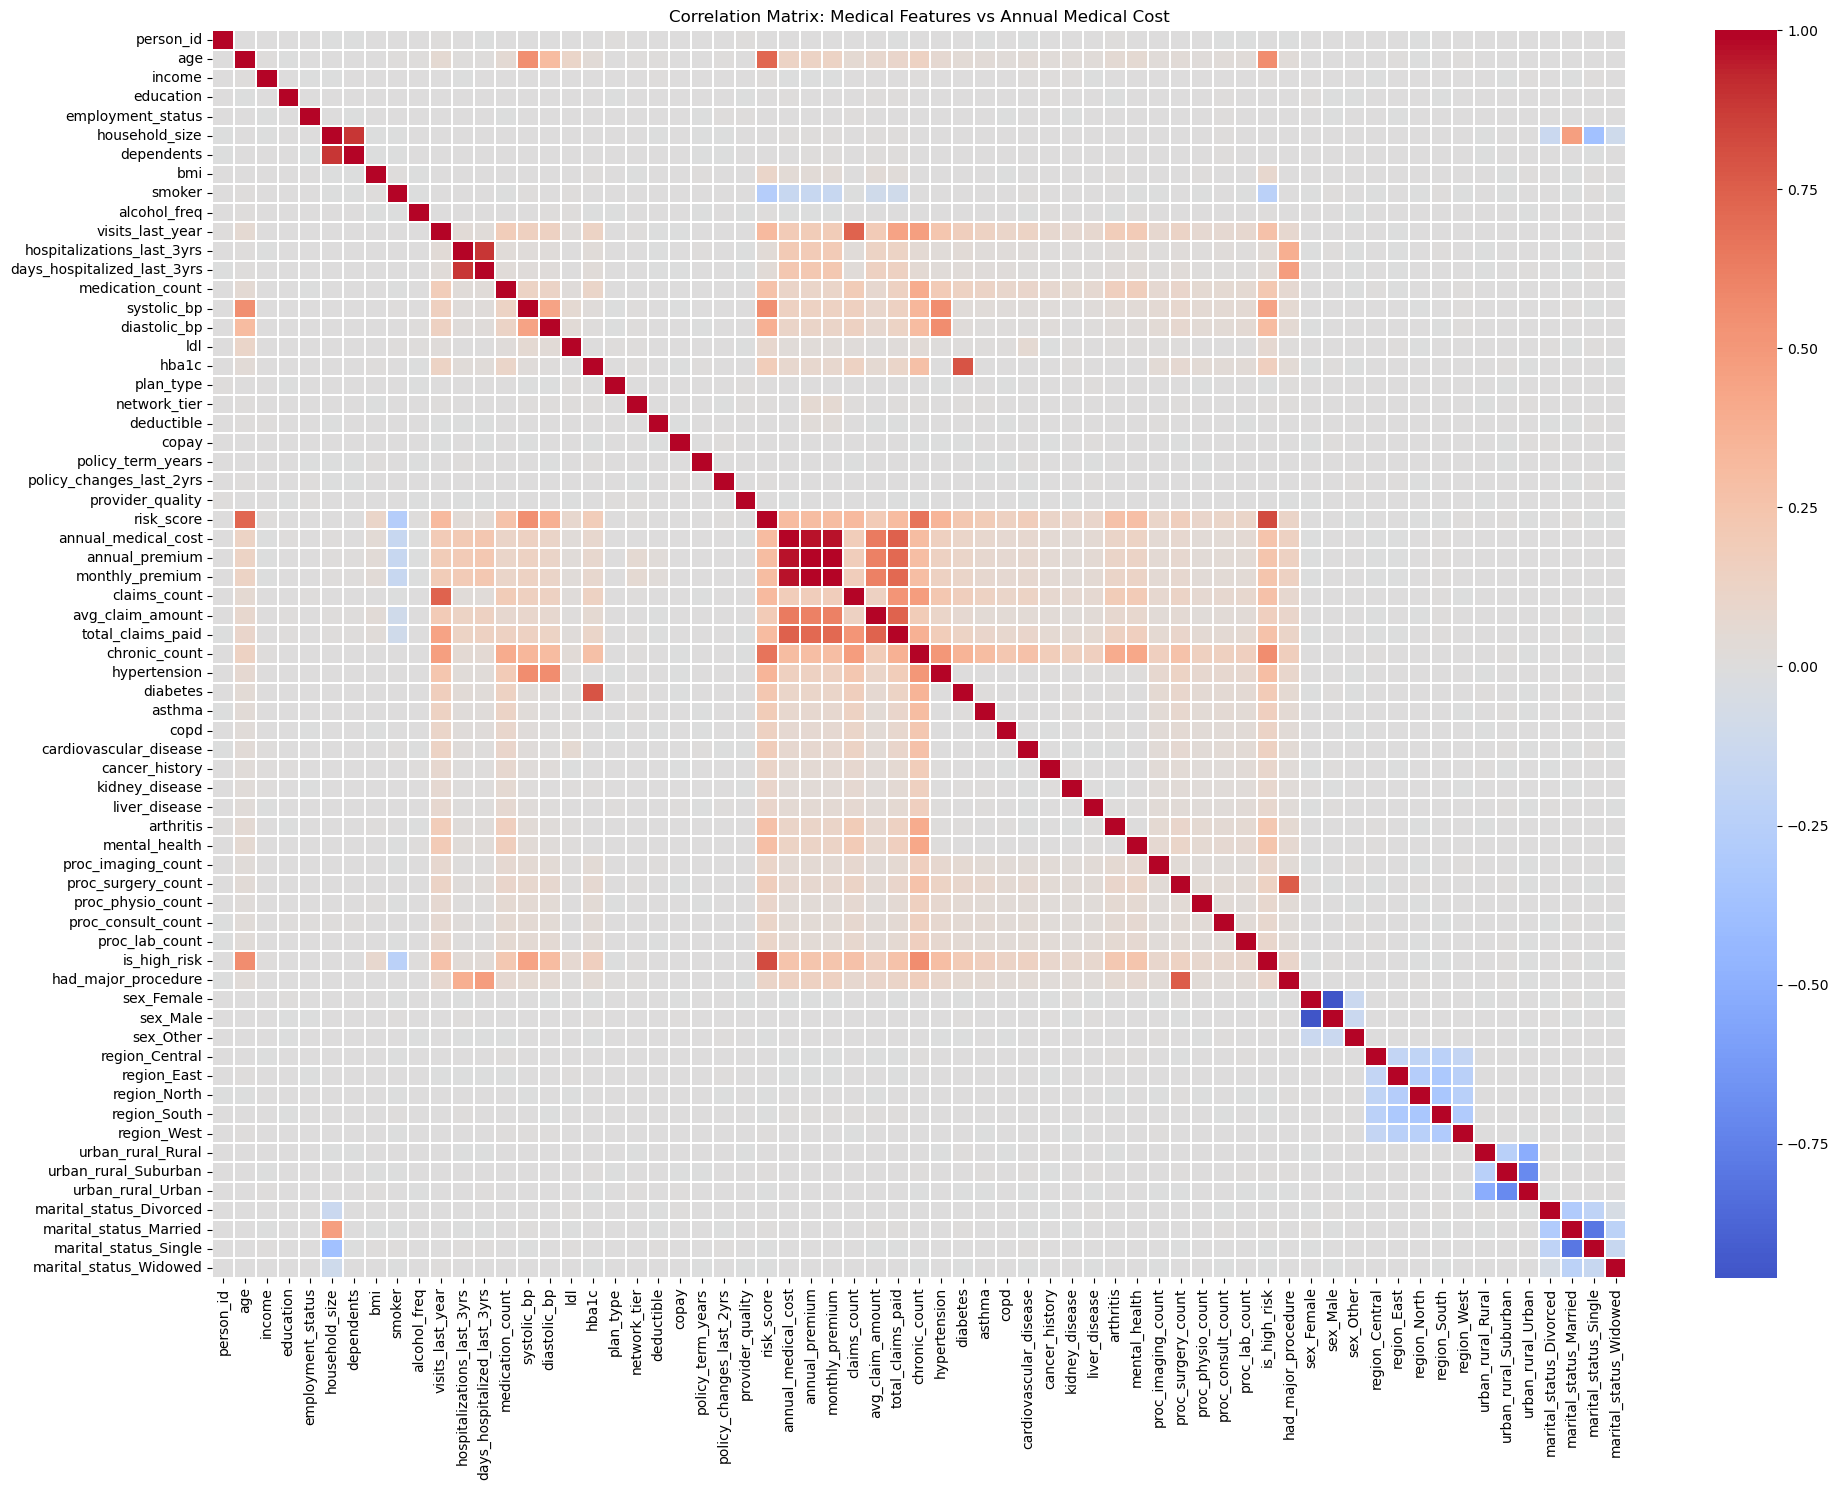

In [5]:
# Correlation heatmap
corr = df.corr()
plt.figure(figsize=(20,15))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title("Correlation Matrix: Medical Features vs Annual Medical Cost")
plt.tight_layout()
plt.show()

### Feature relevance decision

In [6]:
def _is_binary_like(series):
    vals = series.dropna().unique()
    if len(vals) != 2:
        return False
    if pd.api.types.is_bool_dtype(series):
        return True
    lower = [str(v).strip().lower() for v in vals]
    binary_tokens = set(['yes','no','y','n','true','false','t','f','male','female','m','f','1','0'])
    return any(tok in binary_tokens for tok in lower)

def meaningful_binary_map(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s in {'yes','y','true','t','1','male','m','high','risk','positive'}:
        return 1
    if s in {'no','n','false','f','0','female','fem','low','healthy','negative'}:
        return 0
    if s.isdigit():
        return int(s)
    return 1 if s >= 'm' else 0

# ---------------------------
# Correlation matrix
# ---------------------------
corr_df = df.dropna(axis=1, how='all').loc[:, df.nunique() > 1].corr()

# Identify columns used in correlation matrix
included_cols = set(corr_df.columns)
all_cols = set(df.columns)

# Columns dropped from correlation calculation
missing_from_corr = all_cols - included_cols

if missing_from_corr:
    print("⚠️ Columns not included in correlation matrix:")
    for col in missing_from_corr:
        reason = []
        if df[col].isna().all():
            reason.append("all NaN")
        elif df[col].nunique() <= 1:
            reason.append("constant / only one unique value")
        elif not np.issubdtype(df[col].dtype, np.number):
            reason.append(f"non-numeric ({df[col].dtype})")
        else:
            reason.append("unknown reason")
        print(f"  - {col}: {', '.join(reason)}")
else:
    print("✅ All columns were included.")
# ---------------------------
# Target correlation
# ---------------------------
if target not in corr_df.columns:
    raise ValueError(f"Target column '{target}' not found in correlation matrix. Check data.")

target_corr = corr_df[target].drop(target).sort_values(ascending=False)
print("TOP FEATURES BY PEARSON CORRELATION WITH TARGET:")
print(target_corr.head(15))
print()

# ---------------------------
# Pearson significance
# ---------------------------
significant_features = []
for feat in target_corr.index:
    try:
        x = df_enc[feat].dropna()
        y = df_enc.loc[x.index, target]
        common_index = x.index.intersection(y.index)
        if len(common_index) < 10:
            continue
        corr_coef, p_val = pearsonr(x.loc[common_index], y.loc[common_index])
        if not np.isnan(p_val) and p_val < 0.05:
            significant_features.append((feat, corr_coef, p_val))
    except Exception:
        continue

significant_features = sorted(significant_features, key=lambda x: abs(x[1]), reverse=True)
print("STATISTICALLY SIGNIFICANT PEARSON CORRELATIONS (p < 0.05):")
for feat, coef, p in significant_features[:20]:
    print(f"{feat:30s} | r = {coef:6.3f} | p = {p:.4g}")
print()

# ---------------------------
# Multicollinearity
# ---------------------------
high_corr_pairs = []
cols_corr = corr_df.columns.tolist()
for i in range(len(cols_corr)):
    for j in range(i+1, len(cols_corr)):
        if cols_corr[i] == target or cols_corr[j] == target:
            continue
        val = corr_df.iloc[i, j]
        if abs(val) > 0.75:
            high_corr_pairs.append((cols_corr[i], cols_corr[j], val))

if high_corr_pairs:
    print("HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.75):")
    for a, b, v in high_corr_pairs:
        print(f"{a:25s} <--> {b:25s} : {v:6.3f}")
else:
    print("No very high feature-feature correlations found (threshold 0.75).")
print()

# ---------------------------
# Prepare modeling dataset (drop rows with NA for model features)
# ---------------------------
model_features = [c for c in df.columns if c != target]
# drop columns that are completely non-numeric just in case
numeric_model_features = [c for c in model_features if np.issubdtype(df[c].dtype, np.number)]

# create modeling dataframe (drop rows with NA in selected numeric features + target)
df_model = df[[target] + numeric_model_features].dropna(axis=0, how='any').copy()

print("Modeling dataset size (after dropna):", df_model.shape)

X = df_model[numeric_model_features]
y = df_model[target]

# ---------------------------
# RandomForest
# ---------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_importances = pd.DataFrame({
    'feature': numeric_model_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nRANDOM FOREST FEATURE IMPORTANCE (top 15):")
print(rf_importances.head(15).to_string(index=False))

# ---------------------------
# SelectKBest (F-test) using scaled continuous features
# ---------------------------
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_scaled, y)
feature_scores = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False).reset_index(drop=True)

print("\nSELECTKBEST (F-test) SCORES (top 15):")
print(feature_scores.head(15).to_string(index=False))

# ---------------------------
# Combined scoring (heuristic)
# ---------------------------
feature_summary = {}
for feat in numeric_model_features:
    score = 0
    corr_val = abs(target_corr.get(feat, 0.0))
    if corr_val > 0.25:
        score += 3
    elif corr_val > 0.10:
        score += 2
    elif corr_val > 0.05:
        score += 1

    p_row = feature_scores[feature_scores['feature'] == feat]
    if not p_row.empty:
        p_val = float(p_row['p_value'].iloc[0])
        if p_val < 0.001:
            score += 3
        elif p_val < 0.01:
            score += 2
        elif p_val < 0.05:
            score += 1

    rf_idx = rf_importances[rf_importances['feature'] == feat].index
    if len(rf_idx) > 0:
        rf_rank = int(rf_idx[0])
        if rf_rank < 3:
            score += 2
        elif rf_rank < 6:
            score += 1

    feature_summary[feat] = score

final_scores = sorted(feature_summary.items(), key=lambda x: x[1], reverse=True)

print("\nFINAL FEATURE RANKING (heuristic score):")
print(f"{'Rank':>4} | {'Feature':30s} | {'Score':>5} | Recommendation")
for i, (feat, sc) in enumerate(final_scores, 1):
    rec = "KEEP" if sc >= 5 else ("KEEP (consider)" if sc >= 3 else "DROP / LOW")
    print(f"{i:4d} | {feat:30s} | {sc:5d} | {rec}")

# ---------------------------
# Redundancy cleanup
# ---------------------------
redundant_drops = set()
for a, b, val in high_corr_pairs:
    corr_a = abs(target_corr.get(a, 0.0))
    corr_b = abs(target_corr.get(b, 0.0))
    if corr_a >= corr_b:
        keep, drop = a, b
    else:
        keep, drop = b, a
    redundant_drops.add(drop)
    print(f"REDUNDANCY: KEEP {keep:30s} | DROP {drop:30s} (pair corr={val:0.3f})")

if redundant_drops:
    print("\nFinal suggested drops due to redundancy:")
    for d in redundant_drops:
        print(" -", d)
else:
    print("\nNo redundancy-based drops suggested.")

# ---------------------------
# Final selected features
# ---------------------------
selected_features = [feat for feat, score in final_scores if score >= 3 and feat not in redundant_drops]
print(f"\nFINAL SELECTED FEATURES ({len(selected_features)}):")
for f in selected_features:
    print(" -", f)


# ---------------------------
# Auto-drop based on earlier analysis (redundancy + heuristic)
# ---------------------------

# Build set of redundant drops (from high_corr_pairs) if not already available
if 'high_corr_pairs' not in globals():
    high_corr_pairs = []
    cols_corr = corr_df.columns.tolist()
    for i in range(len(cols_corr)):
        for j in range(i+1, len(cols_corr)):
            if cols_corr[i] == target or cols_corr[j] == target:
                continue
            val = corr_df.iloc[i, j]
            if abs(val) > 0.75:
                high_corr_pairs.append((cols_corr[i], cols_corr[j], val))

redundant_drops_auto = set()
for a, b, val in high_corr_pairs:
    corr_a = abs(target_corr.get(a, 0.0))
    corr_b = abs(target_corr.get(b, 0.0))
    if corr_a > corr_b:
        keep, drop = a, b
    elif corr_b > corr_a:
        keep, drop = b, a
    else:
        keep, drop = min(a, b), max(a, b)
    redundant_drops_auto.add(drop)

# Low-score drops from your heuristic (score < 3)
low_score_drops = set([feat for feat, sc in feature_summary.items() if sc < 3])

# Combine drops
final_drops = (redundant_drops_auto.union(low_score_drops)) - {target}

# Intersect with df_enc columns for safety
cols_to_drop = [c for c in final_drops if c in df.columns]

print("\nAUTO DROP SUMMARY")
print(" - redundant_drops_auto:", sorted(redundant_drops_auto))
print("\n")
print(" - low_score_drops:", sorted(low_score_drops)[:30])
print("\n")
print(" - cols_to_drop (final):", cols_to_drop)

# Apply drops to produce df_selected and df_model (numeric only)
df_selected = df.drop(columns=cols_to_drop, errors='ignore').copy()

model_features = [c for c in df_selected.columns if c != target and np.issubdtype(df_selected[c].dtype, np.number)]
df_model = df_selected[[target] + model_features].dropna(axis=0, how='any').copy()


print("\ndf_selected shape (after auto-drop):", df_selected.shape)
print("Modeling dataset size (after dropna):", df_model.shape)

# Persist lists for reproducibility
final_drops_list = cols_to_drop
final_features = model_features

# ---------------------------
# Summary
# ---------------------------
print("\n=== SUMMARY ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Modeling rows used (after dropna): {df_model.shape[0]}")
print(f"Top RF feature: {rf_importances.iloc[0]['feature'] if not rf_importances.empty else 'N/A'}")
print("Top correlated features (abs r):")
for f, v in list(target_corr.abs().items())[:8]:
    print(f" - {f}: {v:0.3f}")

✅ All columns were included.
TOP FEATURES BY PEARSON CORRELATION WITH TARGET:
monthly_premium                0.965028
annual_premium                 0.965028
total_claims_paid              0.740226
avg_claim_amount               0.633333
risk_score                     0.307861
chronic_count                  0.298067
is_high_risk                   0.253741
days_hospitalized_last_3yrs    0.229908
hospitalizations_last_3yrs     0.208346
visits_last_year               0.197533
claims_count                   0.180844
hypertension                   0.155347
had_major_procedure            0.149006
systolic_bp                    0.146034
age                            0.131649
Name: annual_medical_cost, dtype: float64

STATISTICALLY SIGNIFICANT PEARSON CORRELATIONS (p < 0.05):

HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.75):
household_size            <--> dependents                :  0.886
hospitalizations_last_3yrs <--> days_hospitalized_last_3yrs :  0.886
hba1c                     <--> diabete

## Step-4- Training Model Analysis

In [7]:
if 'monthly_premium' in df_model.columns:
    # Select "safe" numeric features
    safe_features = [
        col for col in df_model.columns
        if col not in [
            'monthly_premium', 'annual_premium', 'annual_medical_cost',
            'total_claims_paid', 'avg_claim_amount'
        ]
    ]
    X_no_leak = df_model[safe_features].select_dtypes(include=[np.number]).fillna(0)
    y_premium = df_model['monthly_premium']

    # Fit linear regression to predict monthly_premium
    lr_premium = LinearRegression()
    lr_premium.fit(X_no_leak, y_premium)

    # Compute residuals
    df_model['monthly_premium_residual'] = y_premium - lr_premium.predict(X_no_leak)

    # Drop original monthly_premium to avoid leakage
    df_model.drop(columns=['monthly_premium'], inplace=True)

    print("✅ Added 'monthly_premium_residual' and removed 'monthly_premium'.\n")

    # -----------------------------------------------
    # LOWER FEATURE IMPORTANCE OF monthly_premium_residual for better generalization
    # -----------------------------------------------

    # Method 1: scale down its magnitude
    scale_factor = 0.5
    df_model['monthly_premium_residual'] *= scale_factor

    # Method 2: add light noise to reduce stability
    noise_strength = 0.01
    df_model['monthly_premium_residual'] += np.random.normal(
        0,
        df_model['monthly_premium_residual'].std() * noise_strength,
        size=len(df_model)
    )

    print(f" Scaled down 'monthly_premium_residual' by {scale_factor} and added {noise_strength*100:.0f}% noise.")

✅ Added 'monthly_premium_residual' and removed 'monthly_premium'.

 Scaled down 'monthly_premium_residual' by 0.5 and added 1% noise.


Index(['annual_medical_cost', 'age', 'bmi', 'smoker', 'visits_last_year',
       'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp',
       'diastolic_bp', 'ldl', 'risk_score', 'claims_count', 'avg_claim_amount',
       'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes',
       'asthma', 'copd', 'cardiovascular_disease', 'cancer_history',
       'kidney_disease', 'liver_disease', 'arthritis', 'mental_health',
       'proc_imaging_count', 'proc_physio_count', 'proc_consult_count',
       'proc_lab_count', 'had_major_procedure', 'monthly_premium_residual'],
      dtype='object')
📦 PREPARING DATA FROM df_model
✓ Training samples: 79,992
✓ Test samples: 19,998
✓ Number of features: 30
🚀 TRAINING MODELS (df_model)

⚙️ Training Linear Regression...
   ✓ R²=0.9424 | RMSE=$769.32 | MAE=$450.36 | MAPE=18.12%

⚙️ Training Ridge...
   ✓ R²=0.9424 | RMSE=$769.33 | MAE=$450.39 | MAPE=18.13%

⚙️ Training Lasso...
   ✓ R²=0.9420 | RMSE=$771.87 | MAE=$453.16 | MAPE=18.51%



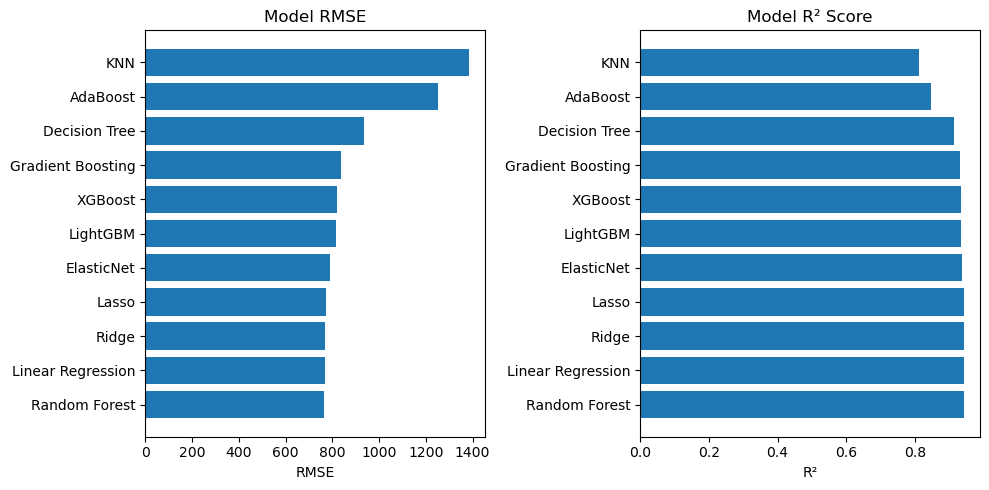


Top 15 features for LightGBM:
                    Feature  Importance
   monthly_premium_residual       14829
          total_claims_paid        8144
           avg_claim_amount        6366
                        bmi        5475
                 risk_score        5034
                        ldl        4999
days_hospitalized_last_3yrs        4921
                        age        4234
                systolic_bp        4001
               diastolic_bp        3636
              chronic_count        2558
           visits_last_year        2439
               claims_count        2359
                     smoker        2012
           medication_count        1267


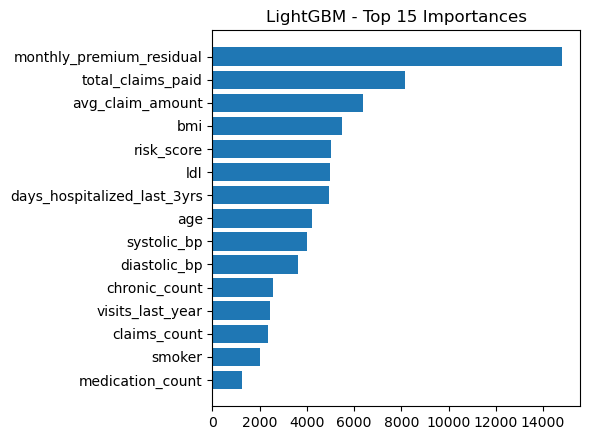

In [8]:
try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None
    
print(df_model.columns)

target = 'annual_medical_cost'

print("="*70)
print("📦 PREPARING DATA FROM df_model")
print("="*70)

# Prepare features (numeric only)
X = df_model.drop(columns=[target], errors='ignore').select_dtypes(include=[np.number])
y = df_model[target]

# Fill NaN with mean
X = X.fillna(X.mean())

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Scale for linear & KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Training samples: {X_train.shape[0]:,}")
print(f"✓ Test samples: {X_test.shape[0]:,}")
print(f"✓ Number of features: {X.shape[1]}")

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=10.0, random_state=RANDOM_STATE, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE, learning_rate=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=10),
    'KNN': KNeighborsRegressor(n_neighbors=7)
}

if XGBRegressor is not None:
    models['XGBoost'] = XGBRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, 
                                     eval_metric='rmse', max_depth=7, learning_rate=0.1)
if LGBMRegressor is not None:
    models['LightGBM'] = LGBMRegressor(
    n_estimators=1500,   # more trees with early stopping
    max_depth=7,         # slightly deeper
    learning_rate=0.02,  # slower learning
    num_leaves=55,
    min_child_samples=15,
    subsample=0.95,
    colsample_bytree=0.85,
    random_state=RANDOM_STATE,
    verbose=-1
)

# Train and evaluate
results = []
trained_models = {}

print("="*70)
print("🚀 TRAINING MODELS (df_model)")
print("="*70)

for name, model in models.items():
    print(f"\n⚙️ Training {name}...")
    start = time.time()

   # Use scaled data for linear/KNN
    if name in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'KNN']:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    model.fit(X_tr, y_train)
    y_pred = np.maximum(model.predict(X_te), 0)  # clip negative preds
    elapsed = time.time() - start

    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({
        'Model': name,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'Time (s)': elapsed
    })
    trained_models[name] = model

    print(f"   ✓ R²={r2:.4f} | RMSE=${rmse:,.2f} | MAE=${mae:,.2f} | MAPE={mape:.2f}%")

# Show results
results_df = pd.DataFrame(results).sort_values(by='RMSE', ascending=True).reset_index(drop=True)

print("\n" + "="*70)
print("📊 MODEL PERFORMANCE SUMMARY")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)
print("\n")

# RMSE and R² bar plots
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.barh(results_df['Model'], results_df['RMSE'])
plt.xlabel("RMSE"); plt.title("Model RMSE")
plt.subplot(1,2,2)
plt.barh(results_df['Model'], results_df['R²'])
plt.xlabel("R²"); plt.title("Model R² Score")
plt.tight_layout()
plt.show()

# Feature importance for LightGBM
if 'LightGBM' in trained_models:
    best_model = trained_models['LightGBM']
    if hasattr(best_model, 'feature_importances_'):
        fi = pd.DataFrame({'Feature': X.columns, 'Importance': best_model.feature_importances_})
        fi = fi.sort_values('Importance', ascending=False).head(15)
        print(f"\nTop 15 features for LightGBM:")
        print(fi.to_string(index=False))
        plt.figure(figsize=(6, min(0.3*15,6)))
        plt.barh(fi['Feature'][::-1], fi['Importance'][::-1])
        plt.title("LightGBM - Top 15 Importances")
        plt.tight_layout()
        plt.show()
else:
    print("⚠️ LightGBM not trained or not installed.")

##### We can see that the LightGBM model achieves the best accuracy while providing a well-distributed feature importance across predictors.

### Best Model - LightGBM

In [9]:
y_test_pred = best_model.predict(X_test)
y_train_pred = best_model.predict(X_train)

In [10]:
# --- Train metrics ---
r2_train   = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train  = mean_absolute_error(y_train, y_train_pred)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100

# --- Test metrics ---
r2_test   = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test  = mean_absolute_error(y_test, y_test_pred)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100

In [11]:
print(f"Train Set: R²={r2_train:.4f}, RMSE=${rmse_train:,.2f}, MAE=${mae_train:,.2f}, MAPE={mape_train:.2f}%")
print(f"Test Set: R²={r2_test:.4f}, RMSE=${rmse_test:,.2f}, MAE=${mae_test:,.2f}, MAPE={mape_test:.2f}%")

Train Set: R²=0.9711, RMSE=$520.65, MAE=$343.76, MAPE=14.02%
Test Set: R²=0.9353, RMSE=$815.31, MAE=$420.04, MAPE=15.15%


### Cross Validation - LightGBM

In [12]:
# ----------------------------
# 5-FOLD CROSS-VALIDATION FOR LIGHTGBM
# ----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lgb_model = LGBMRegressor(
    n_estimators=1500,
    max_depth=7,
    learning_rate=0.02,
    num_leaves=55,
    min_child_samples=15,
    subsample=0.95,
    colsample_bytree=0.85,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# R² PER FOLD
r2_scores = cross_val_score(lgb_model, X, y, cv=kf, scoring='r2', n_jobs=-1)
print("="*60)
print("📊 LightGBM 5-Fold Cross-Validation Metrics")
print("="*60)
print(f"R²:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")


# RMSE PER FOLD
rmse_scores = []
for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    lgb_model.fit(X_tr, y_tr)
    y_pred = np.maximum(lgb_model.predict(X_te), 0)
    rmse = np.sqrt(np.mean((y_te - y_pred)**2))
    rmse_scores.append(rmse)

rmse_mean = np.mean(rmse_scores)
rmse_std  = np.std(rmse_scores)
print(f"RMSE:  ${rmse_mean:,.2f} ± ${rmse_std:,.2f}")
print("="*60)

📊 LightGBM 5-Fold Cross-Validation Metrics
R²:   0.9336 ± 0.0021
RMSE:  $795.96 ± $24.46


### Export Model

In [15]:
joblib.dump(best_model, 'models/annual_medical_cost_model.pkl')
joblib.dump(list(X.columns), 'features/annual_medical_cost_features.pkl')
joblib.dump(lr_premium, 'models/lr_premium.pkl')
joblib.dump(X_no_leak.columns.tolist(), "features/lr_premium_features.pkl")

['lr_premium_features.pkl']